In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housing-prices-dataset/Housing.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv") 
print(df)


        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [3]:


# Replace all 'yes' and 'no' values (case-insensitive) with 1 and 0
df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0}, inplace=True)

# Save the modified data to a new file (to avoid overwriting accidentally)
df.to_csv("Housing.csv", index=False)

print(df)

        price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    13300000  7420         4          2        3         1          0   
1    12250000  8960         4          4        4         1          0   
2    12250000  9960         3          2        2         1          0   
3    12215000  7500         4          2        2         1          0   
4    11410000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   1820000  3000         2          1        1         1          0   
541   1767150  2400         3          1        1         0          0   
542   1750000  3620         2          1        1         1          0   
543   1750000  2910         3          1        1         0          0   
544   1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
0           0                0           

/tmp/ipykernel_13/1650747327.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0}, inplace=True)


In [4]:
df_clean = df[np.abs((df['price'] - df['price'].mean()) / df['price'].std()) < 3]


In [5]:
X = df.drop('price', axis=1)   # all columns except 'price'
y = df['price']  
print(X)
print(y)

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea furnishingstatus  
0                  0               

In [6]:
# Continue from your existing code



# One-hot encode the 'furnishingstatus' categorical feature
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'), ['furnishingstatus'])],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train) 

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 1754318687330.9092
R² Score: 0.65292426421527


In [7]:
import category_encoders as ce

# ----------------------------
# 🔥 Target Encoding instead of One-Hot
# ----------------------------

# Make a copy of X
X2 = X.copy()

# Apply Target Encoding to furnishingstatus
te = ce.TargetEncoder(cols=['furnishingstatus'])
X2['furnishingstatus'] = te.fit_transform(X2['furnishingstatus'], y)

# No need for column transformer anymore
X_encoded = X2.values  # convert to numpy array for sklearn

# ----------------------------
# Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# ----------------------------
# Train Linear Regression model
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 1761838835910.6714
R² Score: 0.6514364723332244


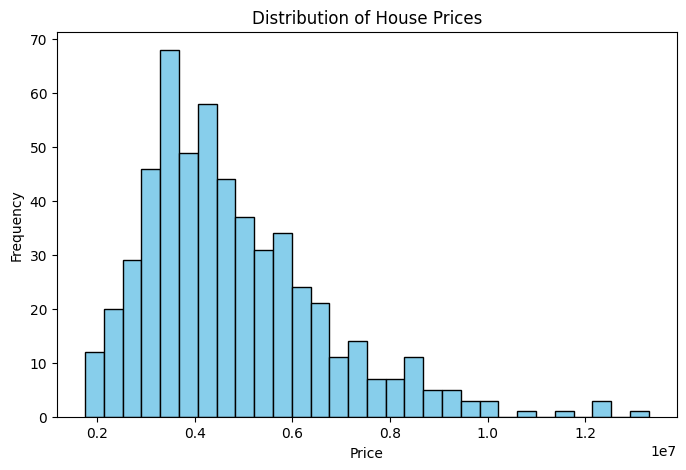

In [8]:
#  Price distribution
plt.figure(figsize=(8,5))
plt.hist(y, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

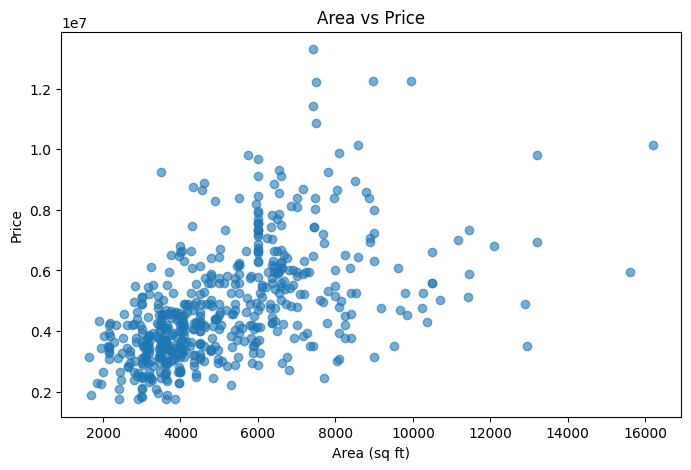

In [9]:
#  Area vs Price
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'], alpha=0.6)
plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.show()

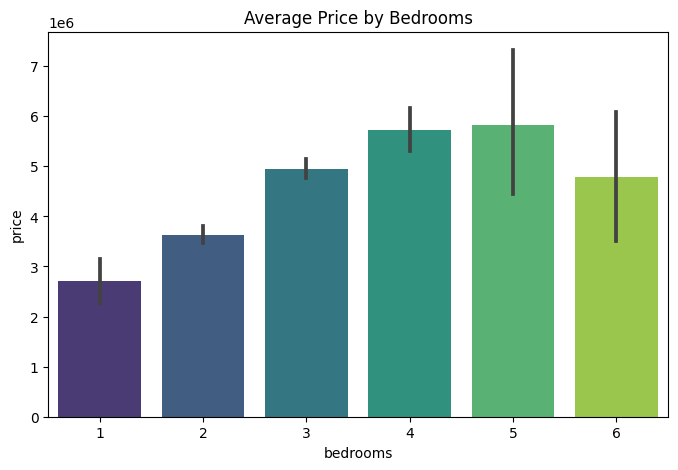

In [10]:
#  Bedrooms vs Price
plt.figure(figsize=(8,5))
sns.barplot(x='bedrooms', y='price', data=df, palette='viridis')
plt.title("Average Price by Bedrooms")
plt.show()

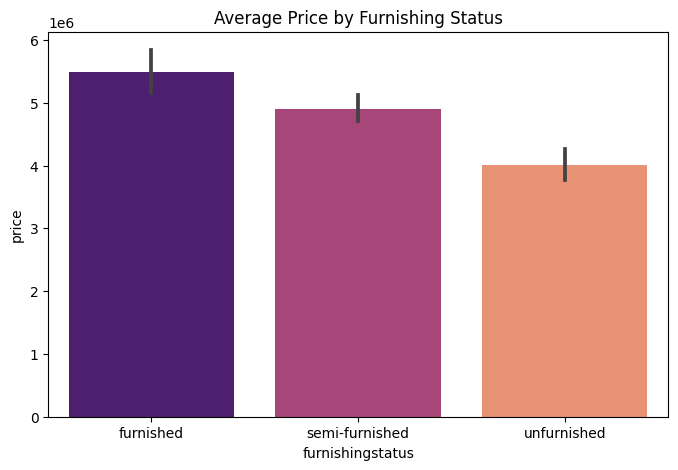

In [11]:
#  Furnishing status vs Price
plt.figure(figsize=(8,5))
sns.barplot(x='furnishingstatus', y='price', data=df, palette='magma')
plt.title("Average Price by Furnishing Status")
plt.show()

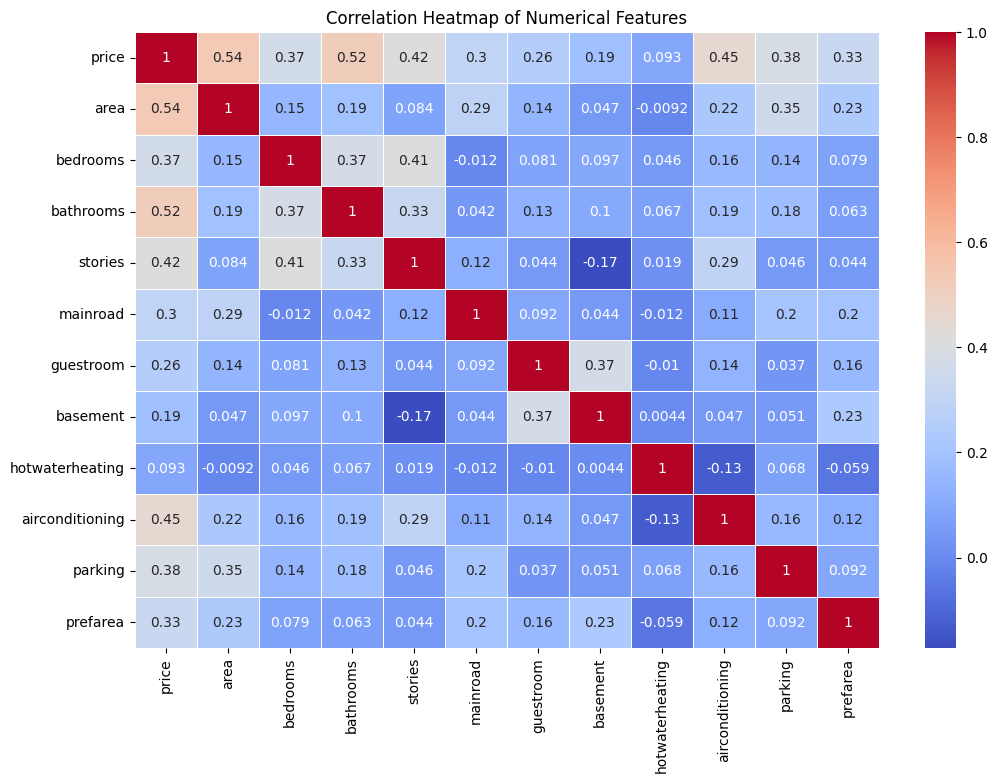

In [12]:
# ===============================
# 🔥 FIXED Heatmap for Numerical Features
# ===============================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
X = df.drop('price', axis=1)
y = df['price']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'), ['furnishingstatus'])],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}")


Random Forest Performance:
MAE  : 1,015,101.43
RMSE : 1,400,223.30
R²   : 0.612


In [14]:
# Make sure new_house has the exact same column order as X
new_house = pd.DataFrame([{
    'area': 5000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 1,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 2,
    'prefarea': 1,
    'furnishingstatus': 'semi-furnished'
}])

# Apply same encoder
new_house_encoded = ct.transform(new_house)

# Predict using the same model you trained
predicted_price = rf.predict(new_house_encoded)

print("Predicted House Price:", round(predicted_price[0], 2))


Predicted House Price: 7450205.0


In [15]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n🏆 Tuned Random Forest Performance:")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}")



🏆 Tuned Random Forest Performance:
MAE  : 1,015,101.43
RMSE : 1,400,223.30
R²   : 0.612


In [16]:
new_house_encoded = ct.transform(new_house)
predicted_price = rf.predict(new_house_encoded)

print(f"🏡 Predicted Price for the New House: {predicted_price[0]:,.2f}")

🏡 Predicted Price for the New House: 7,450,205.00


In [17]:
# ============================================================
# 🚀 XGBoost + Target Encoding + Outlier Removal (No Warnings)
# ============================================================

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Load Data
# -----------------------------
df = pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv")

# -----------------------------
# 2. Convert yes/no → 1/0 using .map()  (NO WARNING)
# -----------------------------
yes_no_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# -----------------------------
# 3. Remove price outliers
# -----------------------------
z_scores = np.abs((df['price'] - df['price'].mean()) / df['price'].std())
df_clean = df[z_scores < 3].reset_index(drop=True)

# -----------------------------
# 4. Split features & target
# -----------------------------
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# -----------------------------
# 5. Target Encode furnishingstatus
# -----------------------------
te = TargetEncoder(cols=['furnishingstatus'])
X['furnishingstatus'] = te.fit_transform(X['furnishingstatus'], y)

# -----------------------------
# 6. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7. XGBoost Model
# -----------------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# -----------------------------
# 8. Predictions + Scores
# -----------------------------
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("🌿 XGBoost Performance:")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}")

# -----------------------------
# 9. Predict for new input
# -----------------------------
new_house = pd.DataFrame([{
    'area': 5000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 1,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 2,
    'prefarea': 1,
    'furnishingstatus': 'semi-furnished'
}])

new_house['furnishingstatus'] = te.transform(new_house[['furnishingstatus']])

predicted_price = xgb_model.predict(new_house)[0]

print("\n🏡 Predicted House Price (XGBoost):", round(predicted_price, 2))


🌿 XGBoost Performance:
RMSE : 1,164,454.05
R²   : 0.646

🏡 Predicted House Price (XGBoost): 8180394.0


In [18]:
# ============================================================
# 🚀 Improved Model: CatBoost + Target Encoding + Outlier Removal
# ============================================================

from catboost import CatBoostRegressor
from category_encoders import TargetEncoder
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Remove price outliers
# -----------------------------
z_scores = np.abs((df['price'] - df['price'].mean()) / df['price'].std())
df_clean = df[z_scores < 3].reset_index(drop=True)

# -----------------------------
# 2. Split features/target again
# -----------------------------
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# -----------------------------
# 3. Target Encode the categorical column
# -----------------------------
te = TargetEncoder(cols=['furnishingstatus'])
X['furnishingstatus'] = te.fit_transform(X['furnishingstatus'], y)

# -----------------------------
# 4. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. CatBoost Model (Strong for Tabular Data)
# -----------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False
)

model.fit(X_train, y_train)

# -----------------------------
# 6. Predictions + Scores
# -----------------------------
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("CatBoost Performance:")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}")

# -----------------------------
# 7. Predict for new input
# -----------------------------
new_house_te = new_house.copy()
new_house_te['furnishingstatus'] = te.transform(new_house_te[['furnishingstatus']])

predicted_price = model.predict(new_house_te)
print("\nPredicted House Price:", round(predicted_price[0], 2))


CatBoost Performance:
RMSE : 1,123,414.17
R²   : 0.671

Predicted House Price: 7547857.96


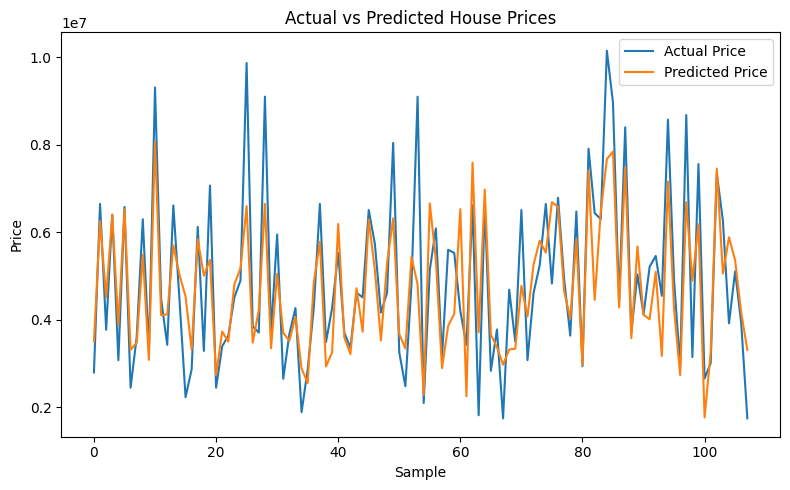

In [19]:
#visualizing the actual vs predicted house prices
plt.figure(figsize=(8,5))

#resetting index for proper alignment in the plot
Y_test_sorted = y_test.reset_index(drop=True)
Y_pred_sorted = pd.Series(y_pred).reset_index(drop=True)

plt.plot(Y_test_sorted, label="Actual Price")
plt.plot(Y_pred_sorted, label="Predicted Price")

plt.xlabel("Sample")
plt.ylabel("Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
#Srajan: Xgboost